In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Baseline Python
This notebook is intended to make a quick scan of different skills. It will test:

- knowledge about mathematical notation (function definitions, sets) and a minimum of linear algebra (matrix multiplication)
- numpy (generating data, concatenating, dotproduct)
- generate a pandas dataframe, basic plotting
- creating a class
- basic efficiency (avoiding forloops with vectorization)
- list comprehensions

Before you do this test, make sure you went through the Vectorisation and
Broadcasting notebook.

# Don't worry if you get stuck
this notebook is meant to identify the subjects
where you will need more explanation!

Some people might have a hard time with the mathematical notation. If so, **write
down your questions and I will explain them**. Others might have no problem with
that, but will have problems with classes, etc. Just use this as a test for
finding the things I need to explain to you.

Work on this, and please also keep track of your time (that gives me an
indication of your working speed. This also differs widely over user groups)

## Excercise 1
### definition 1
>Let there be $m$ observations $x_i \in X$ with $i=\{1, ..., m\}$ where every observation has $n$ features: $x_i=\{x_{i,1}, ..., x_{i,n}\}$ 

We will represent these as a matrix $X$ with dimensions $(m, n)$ such that value $x_{i,j}$ is the $i^{th}$ observation for feature $j$.

### objective

Use numpy to create a matrix $X$ with $m=100, n=2$, filled with random floating point numbers. This will be our set of 100 observations with 2 features.

<details>
  <summary>HINT: Click to expand!</summary>

  You can use `np.random.rand`
  If you are not familiar, you can access the documentation directly from the jupyter notebook, by running either
  `help(np.random.rand)` or `?np.random.rand`
  
</details>

In [2]:
m = 100
n = 2
X = np.random.rand(m, n)
X.shape

(100, 2)

## Excercise 2

### definition 2
>We want to implement a function $f: \mathbb{R}^m \to \mathbb{R}$ such that $$f(x) = wx + b$$
>Here, $w$ are weights $w=\{w_1, ..., w_n\}$ where $n$ corresponds to the number of features and $b$ is an extra bias weight. We will initialize $w$ at random.


**Example** if we observe a person $x_1$, as features let us measure someones height and shoe-size. Let us obtain $x_1=\{1.84, 46\}$.
Now, let our randomly initialized weights $w$ be $\{0.9, 0.2\}$ and our $b=3$. With this, we would need to calculate: $0.9 * 1.84 + 0.2 * 46 + 3$ for that person.
For a next person let us obtain $x_2=\{1.65, 36\}$, and thus we would need to calculate $0.9 * 1.65 + 0.2 * 36 + 3$.

### definition 3
To implement this more efficient, we will redefine the function slightly:
>First, we add a dummy observation of 1 to the features: we get $x_i=\{x_{i,1}, ..., x_{i,n}, 1\}$
>Then, we add the bias to the weights, such that we get $w=\{w_1, ..., w_n, b\}$.
>With this, we can change the formula to $$f(x)= wx$$


**Example** our previous example would be $x_1=\{1.84, 46, 1\}$ and $w=\{0.9, 0.2, 3\}$ and we would calculate $0.9 * 1.84 + 0.2 * 46 + 3 * 1$.

### Objective
To implement this , do the following:
- create a columnvector $Xb$ where all entries are equal to 1, with dimensions $(m, 1)$. This will be the weight used for the bias. Do not hardcode $m$, but retrieve it from $X$.
- concatenate the observations $X$ with $Xb$ along the columns, such that you get a matrix with dimensions $(m, n+1)$.
- initialize a columnvector $w$ where you add the bias as one of the weights. So, it should have dimensions $(n+1, 1)$. Do not hardcode $n$, but retrieve it from $X$.
- calculate $f(x)$ for all $m$
- store the result of your calculation, that should have shape $(m, 1)$ in a variable `yhat`, which refers to your prediction $\hat{y}$ 

<details>
  <summary>HINT: Click to expand!</summary>
  
  For this, you can use the following numpy functions:
  `np.ones`, `np.concatenate`, `np.random.rand` and `np.dot`.
</details>

In [3]:
m, n = X.shape
Xb = np.ones((m, 1))
X_bias = np.concatenate([X, Xb], axis=1)
w = np.random.rand(n + 1, 1)
yhat = np.dot(X_bias, w)
yhat.shape

(100, 1)

## Excercise 3

### Objective
- concatenate $X$ and your prediction `yhat`
- put them in a pandas dataframe, with column names 'height', 'shoe', 'bias' and 'yhat'.
- make a scatterplot, with on the x-axis 'height', on the y-axis 'shoe', and use 'yhat' as a color.

Make sure you have:
- labels 'height' and 'shoe' on the x and y axis
- a legend for the color
- a title 'prediction'


<details>
  <summary>HINT: Click to expand!</summary>

  For this excercise, you can use `np.concatenate`, `pd.DataFrame`, `sns.scatterplot` and `plt.title`.
  Alternatively, you can completely use matplotlib `plt.scatter` or `plt.plot` for plotting, but getting the colors right will take much more coding then the sns.scatterplot oneliner.
  
</details>



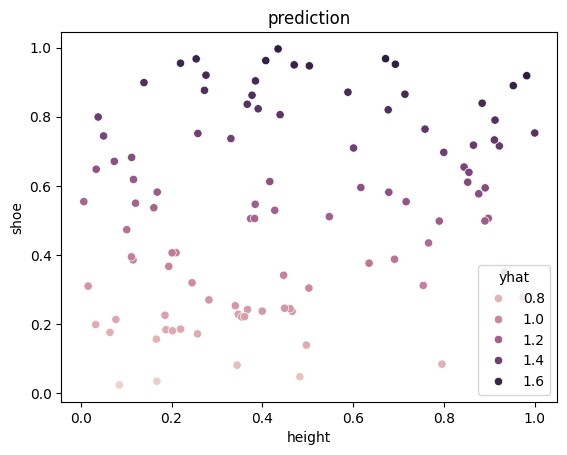

In [4]:
data = np.concatenate([X_bias, yhat], axis=1)
df = pd.DataFrame(data, columns=["height", "shoe", "bias", "yhat"])
sns.scatterplot(data=df, x="height", y="shoe", hue="yhat")
plt.title("prediction")
plt.show()

## Excercise 4

### Objective
Create a class `LinearFunction` with three functions: `__init__`, `generate` and `predict`:

*\_\_init__*
- on initialization you pass variables $m$ and $n$, corresponding to $m$ observations with $n$ features.
- store the original $(m,n)$ dimensions as a tuple in the object
- you call the `generate` function

*generate*
- initialize random data using variables $n$ and $m$, add a column for the bias, 
- generate weights
- store data and weights in the object

*predict*
- you return the result of $f(x)=wx+b$


<details>
  <summary>HINT: Click to expand!</summary>

  This is mainly stitching together the previous lines of code into functions and a class.
  So just reuse what you did before, and make sure everything works inside a function.
  
</details>

In [5]:
import numpy as np


class LinearFunction:
    def __init__(self, n, m):
        self.shape = (n, m)
        self.generate()

    def generate(self):
        n, m = self.shape
        X = np.random.rand(n, m)
        self.X = np.concatenate([X, np.ones((n, 1))], axis=1)
        self.w = np.random.rand(m + 1, 1)

    def predict(self):
        return np.dot(self.X, self.w)

## Excercise 5
If you have implemented your formula efficiently, you should be able to scale it up.

In [6]:
%%time
small = LinearFunction(1000, 3)
yhat = small.predict()

CPU times: user 435 μs, sys: 956 μs, total: 1.39 ms
Wall time: 820 μs


The next function should run in seconds. On my laptop (2.4 GHz Quad-Core Intel i5), I runs in 1.7 seconds.
If it takes much longer, you didnt implement it efficiently and should go back to the implementation.

In [7]:
%%time
big = LinearFunction(100000, 1000)
yhat = big.predict()
len(yhat)

CPU times: user 258 ms, sys: 354 ms, total: 612 ms
Wall time: 771 ms


100000

The code will test this solution for linear growing numbers (factor 10) of observations and features.
The time it takes to compute should not grow with a factor 10, but slower.
If the previous code did not run fast (eg around 2 seconds, but definitely below 10 sec) you should either fix that, or reduce the maximum numbers in the ranges.

In [8]:
nrange = range(2,5)
mrange = range(1,4)
heatmap_vec = np.zeros((len(nrange),len(mrange)))

for i, n in enumerate([10**i for i in nrange]):
    for j, m in enumerate([10**i for i in mrange]):
        func = LinearFunction(n, m)
        looptime = %timeit -o func.predict()
        heatmap_vec[i, j] = looptime.average

1.15 μs ± 48.4 ns per loop (mean ± std. dev. of 7 runs, 1,000,000 loops each)
1.26 μs ± 50.5 ns per loop (mean ± std. dev. of 7 runs, 1,000,000 loops each)
2.8 μs ± 126 ns per loop (mean ± std. dev. of 7 runs, 100,000 loops each)
3.05 μs ± 30 ns per loop (mean ± std. dev. of 7 runs, 100,000 loops each)
3.99 μs ± 59.9 ns per loop (mean ± std. dev. of 7 runs, 100,000 loops each)
19.3 μs ± 414 ns per loop (mean ± std. dev. of 7 runs, 100,000 loops each)
21.1 μs ± 197 ns per loop (mean ± std. dev. of 7 runs, 10,000 loops each)
31.1 μs ± 240 ns per loop (mean ± std. dev. of 7 runs, 10,000 loops each)
1.15 ms ± 15.5 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)


<Axes: >

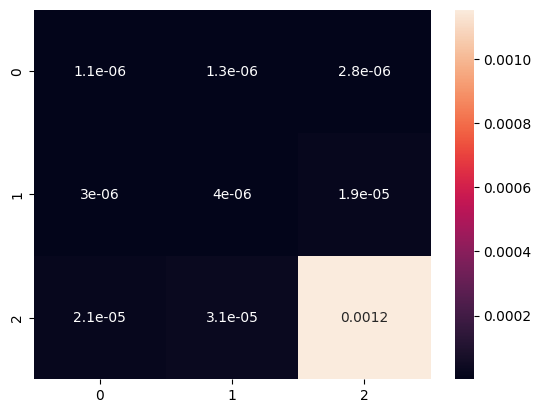

In [9]:
sns.heatmap(heatmap_vec, annot=heatmap_vec)

## Excercise 6
Define a variable `threshold=1`.
Create a list comprehension that runs through the yhat, and assigns a value -1 for every value smaller then the threshold, else 1.

In [10]:
threshold = 1
labels = [-1 if value < threshold else 1 for value in yhat]
labels[:10]

[1, 1, 1, 1, 1, 1, 1, 1, 1, 1]

Make a list comprehension that will select every item in X, if it is larger than
2.

In [11]:
X = [1, 2, 3, 4, 5]
select = [x for x in X if x > 2]
if select:
    assert select == [3, 4, 5]

Make a list comprehension that has the same result as this nested forloop:

In [12]:
Z = ["a", "b", "c"]

out = []
for x in X:
    for z in Z:
        out.append(str(x) + z)
out

['1a',
 '1b',
 '1c',
 '2a',
 '2b',
 '2c',
 '3a',
 '3b',
 '3c',
 '4a',
 '4b',
 '4c',
 '5a',
 '5b',
 '5c']

In [13]:
out2 = [str(x) + z for x in X for z in Z]
if out2:
    assert out == out2


Make a list comprehension that both unpacks the values in the dictionary AND
inverts the dictionary.

hint: use a dict-comprehension, eg:

In [14]:
d = {"a" : 1, "b" : 2}
{v:k for k,v in d.items()}

{1: 'a', 2: 'b'}

Now recreate the nested forloop below with a dict-comprehension

In [15]:
nested_data = {"a" : [1,2,3],
               "b" : [10, 20, 30]}

new_dict = {}
for k,values in nested_data.items():
    for v in values:
        new_dict[v] = k
new_dict

{1: 'a', 2: 'a', 3: 'a', 10: 'b', 20: 'b', 30: 'b'}

In [16]:
new_dict2 = {v: k for k, values in nested_data.items() for v in values}
if new_dict2:
    assert new_dict == new_dict2